In [46]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — Import thư viện
# ═══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score,silhouette_score

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 20)
print('✅ Import xong')

✅ Import xong


In [47]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — Load dữ liệu
# ═══════════════════════════════════════════════════════════════════
MOVIES_PATH  = 'movies.csv'
RATINGS_PATH = 'ratings.csv'
# Nếu dùng Google Colab Drive, đổi thành:
# MOVIES_PATH  = '/content/drive/MyDrive/Movie Recommendation/Dataset/movies.csv'
# RATINGS_PATH = '/content/drive/MyDrive/Movie Recommendation/Dataset/ratings.csv'

movies  = pd.read_csv(MOVIES_PATH)
ratings = pd.read_csv(RATINGS_PATH)

print(f'movies  : {movies.shape[0]:,} phim, {movies.shape[1]} cột')
print(f'ratings : {ratings.shape[0]:,} ratings | {ratings["userId"].nunique()} users | {ratings["movieId"].nunique()} phim')
print(f'Rating range: {ratings["rating"].min()} – {ratings["rating"].max()}')
display(movies.head(3))
display(ratings.head(3))

movies  : 9,742 phim, 3 cột
ratings : 100,836 ratings | 610 users | 9724 phim
Rating range: 0.5 – 5.0


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224


In [48]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — Tiền xử lý: Xây dựng ma trận User × Genre
#
# Giá trị mỗi ô = centered rating:
#   centered(user, genre) = avg_rating(user với genre đó) - avg_rating(user toàn bộ)
#
# Ví dụ:
#   User trung bình = 3.5
#   Comedy avg = 4.25  →  +0.75  (thật sự thích)
#   Sci-Fi avg = 3.0   →  -0.50  (ít thích hơn bình thường)
#   Action     = chưa xem → 0.0  (neutral)
#
# Mục đích: loại bỏ bias người dùng nào cũng cho điểm cao/thấp
# ═══════════════════════════════════════════════════════════════════

# Bước 1: One-hot encode genres  →  'Action|Comedy' thành cột nhị phân
movies_expanded = movies.join(movies['genres'].str.get_dummies('|'))
genre_cols = sorted([c for c in movies_expanded.columns
                     if c not in ['movieId', 'title', 'genres', '(no genres listed)']])
print(f'Số genres: {len(genre_cols)}  →  {genre_cols}')

# Bước 2: Merge ratings với genre flags
df = pd.merge(ratings, movies_expanded[['movieId'] + genre_cols], on='movieId')

# Bước 3: Tính user_avg và rating_count
user_stats     = ratings.groupby('userId')['rating'].agg(user_avg='mean', rating_count='count').reset_index()
user_avg_series = user_stats.set_index('userId')['user_avg']

# Bước 4: Tính centered rating
#   genre_sum(user, genre)   = Σ rating × genre_flag  (chỉ tính phim thuộc genre đó)
#   genre_count(user, genre) = số phim user đã xem thuộc genre đó
#   genre_avg                = genre_sum / genre_count
#   centered                 = genre_avg - user_avg    (0.0 nếu chưa xem)
genre_sum   = df.groupby('userId')[genre_cols].apply(
    lambda grp: grp.multiply(df.loc[grp.index, 'rating'], axis=0).sum()
)
genre_count = df.groupby('userId')[genre_cols].sum()
genre_avg   = genre_sum.div(genre_count.replace(0, np.nan))

user_genre_df = genre_avg.sub(user_avg_series, axis=0).fillna(0.0)
user_genre_df['user_avg']     = user_avg_series
user_genre_df['rating_count'] = user_stats.set_index('userId')['rating_count']

print(f'\nMa trận User × Genre shape: {user_genre_df[genre_cols].shape}  (users × genres)')
print('\nVí dụ 10 user đầu (19 genre ):')
display(user_genre_df[genre_cols[:19] + ['user_avg', 'rating_count']].head(20))

Số genres: 19  →  ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Ma trận User × Genre shape: (610, 19)  (users × genres)

Ví dụ 10 user đầu (19 genre ):


,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,user_avg,rating_count
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.044157,0.021856,0.323276,0.181240,-0.089271,-0.010824,0.000000,0.163032,-0.068507,0.633621,...,0.000000,0.315439,-0.199713,-0.058687,-0.141379,-0.220925,0.133621,-0.080665,4.366379,232
2,0.006270,0.218391,0.000000,0.000000,0.051724,-0.148276,0.385057,-0.065923,0.000000,0.000000,...,-0.198276,0.000000,0.051724,0.551724,-0.073276,-0.248276,0.551724,-0.448276,3.948276,29
3,1.135531,0.291375,-1.935897,-1.935897,-1.435897,-1.935897,0.000000,-1.685897,0.939103,0.000000,...,0.000000,-1.935897,2.564103,-1.935897,1.764103,1.706960,-1.935897,0.000000,2.435897,39
4,-0.235556,0.099617,0.444444,0.244444,-0.045940,0.259259,0.444444,-0.072222,0.128655,0.444444,...,-0.555556,0.444444,-0.077295,-0.176245,-0.722222,-0.002924,0.015873,0.244444,3.555556,216
5,-0.525253,-0.386364,0.696970,0.474747,-0.169697,0.196970,0.000000,0.163636,0.506494,0.000000,...,0.030303,0.763636,0.363636,-0.545455,-1.136364,-0.080808,-0.303030,-0.636364,3.636364,44
6,0.115744,0.399986,0.577798,0.123391,-0.123552,-0.207916,0.000000,0.120655,0.044831,-0.993631,...,1.173036,0.673036,0.239703,0.120655,-0.017440,0.050487,0.089703,0.324551,3.493631,314
7,0.027549,0.084552,0.162594,-0.030263,-0.066998,0.077429,0.000000,-0.098684,-0.165046,0.019737,...,-0.775718,0.436404,-0.051692,-0.580263,-0.075501,0.199969,0.061404,-1.730263,3.230263,152
8,-0.241135,-0.029014,1.425532,0.675532,-0.366135,0.314421,0.000000,0.215006,-0.324468,0.000000,...,0.925532,1.425532,0.425532,-0.074468,-0.324468,0.175532,0.092199,-0.574468,3.574468,47
9,-0.135870,0.539130,0.739130,0.739130,0.405797,-0.118012,0.000000,0.167702,1.739130,0.739130,...,-0.260870,-0.260870,0.739130,-0.094203,-0.260870,-0.715415,0.239130,0.739130,3.260870,46


In [49]:

import pandas as pd
import numpy as np

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

genre_dummies = movies['genres'].str.get_dummies('|')
movies_enc = pd.concat([movies[['movieId']], genre_dummies], axis=1)
genre_cols = [c for c in genre_dummies.columns if c != '(no genres listed)']

merged = ratings.merge(movies_enc, on='movieId')
user_mean = merged.groupby('userId')['rating'].mean()

# Weighted genre average per user
def user_genre_avg(group):
    return group[genre_cols].mul(group['rating'], axis=0).sum() / group[genre_cols].sum().replace(0, np.nan)

user_genre_raw = merged.groupby('userId').apply(user_genre_avg)
centered = user_genre_raw.sub(user_mean, axis=0).fillna(0)

print(f"Value range: [{centered.min().min():.4f}, {centered.max().max():.4f}]")
print(f"Shape: {centered.shape}")


Value range: [-3.5357, 2.5641]
Shape: (610, 19)


In [50]:
def check_neutral_centered(df, genre_cols):
    neutral_counts = (df[genre_cols] == 0.0).sum()
    total_neutral  = neutral_counts.sum()
    total_cells    = len(df) * len(genre_cols)
    
    print(f"Total neutral (0.0) cells : {total_neutral} / {total_cells}")
    print(f"Neutral rate              : {total_neutral / total_cells:.2%}")
    print("\nNeutral count by genre:")
    print(neutral_counts.sort_values(ascending=False))
    
    return neutral_counts

# Usage
check_neutral_centered(user_genre_df, genre_cols)

Total neutral (0.0) cells : 1672 / 11590
Neutral rate              : 14.43%

Neutral count by genre:
Documentary    388
Film-Noir      373
Western        193
IMAX           156
Musical        145
Animation       86
Horror          78
War             64
Children        56
Mystery         35
Fantasy         31
Crime           13
Drama           10
Sci-Fi          10
Romance          8
Thriller         8
Adventure        7
Comedy           6
Action           5
dtype: int64


Action           5
Adventure        7
Animation       86
Children        56
Comedy           6
Crime           13
Documentary    388
Drama           10
Fantasy         31
Film-Noir      373
Horror          78
IMAX           156
Musical        145
Mystery         35
Romance          8
Sci-Fi          10
Thriller         8
War             64
Western        193
dtype: int64

In [51]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — Filter active users & chuẩn hóa dữ liệu
#
# Chỉ đưa user có >= MIN_RATINGS vào clustering.
# User ít rating → vector genre quá thưa (nhiều ô = 0) → làm nhiễu cluster.
# ═══════════════════════════════════════════════════════════════════
MIN_RATINGS = 10

active_mask    = user_genre_df['rating_count'] >= MIN_RATINGS
active_users   = user_genre_df[active_mask]
inactive_users = user_genre_df[~active_mask]

print(f'Active users   (>= {MIN_RATINGS} ratings) : {len(active_users)}')
print(f'Inactive users (<  {MIN_RATINGS} ratings) : {len(inactive_users)}')

# StandardScaler: đưa các genre về cùng scale trước khi K-Means
X_raw    = active_users[genre_cols].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'\nMa trận đưa vào K-Means: {X_scaled.shape}  (users × genres)')

Active users   (>= 10 ratings) : 610
Inactive users (<  10 ratings) : 0

Ma trận đưa vào K-Means: (610, 19)  (users × genres)


In [52]:
# ============================================================
# CELL 5 — Evaluate K Candidates
# ============================================================

k_range = range(2, 15)

results = []

for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    # Evaluation metrics
    sse = km.inertia_

    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    db_index = davies_bouldin_score(
        X_scaled,
        labels
    )

    # Cluster size
    cluster_sizes = pd.Series(labels).value_counts()

    min_cluster_size = cluster_sizes.min()
    max_cluster_size = cluster_sizes.max()

    results.append({
        "K": k,
        "SSE": sse,
        "Silhouette": silhouette,
        "DB_Index": db_index,
        "Min_Cluster_Size": min_cluster_size,
        "Max_Cluster_Size": max_cluster_size
    })


# Convert results to DataFrame
k_results = pd.DataFrame(results)

print("Evaluation results for K = 2 to 14")
display(k_results.round(4))

Evaluation results for K = 2 to 14


,K,SSE,Silhouette,DB_Index,Min_Cluster_Size,Max_Cluster_Size
0,2,10639.9128,0.0911,2.9132,228,382
1,3,10126.9445,0.0536,2.9627,133,270
2,4,9716.5110,0.0374,2.7250,55,255
3,5,9430.9345,0.0638,2.6753,25,279
4,6,9168.5523,0.0292,2.7164,17,229
5,7,8961.1038,0.0390,2.5431,24,200
6,8,8741.3083,0.0232,2.3324,1,193
7,9,8581.3633,0.0278,2.4690,11,197
8,10,8389.0493,0.0282,2.3175,1,172
9,11,8245.3132,0.0287,2.3660,5,122


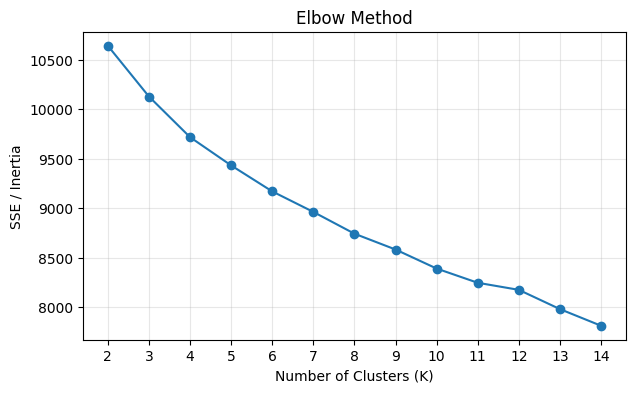

In [53]:
plt.figure(figsize=(7, 4))

plt.plot(
    k_results["K"],
    k_results["SSE"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE / Inertia")
plt.title("Elbow Method")

plt.xticks(k_results["K"])
plt.grid(alpha=0.3)

plt.show()

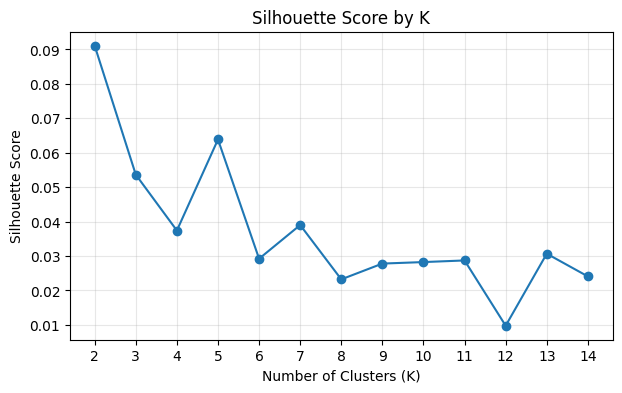

In [54]:
plt.figure(figsize=(7, 4))

plt.plot(
    k_results["K"],
    k_results["Silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")

plt.xticks(k_results["K"])
plt.grid(alpha=0.3)

plt.show()

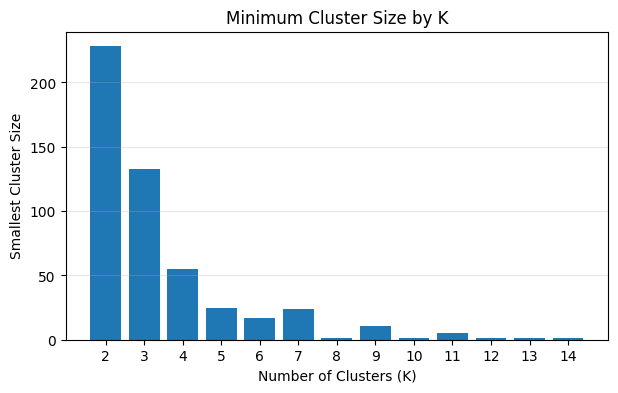

In [55]:
plt.figure(figsize=(7, 4))

plt.bar(
    k_results["K"],
    k_results["Min_Cluster_Size"]
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Smallest Cluster Size")
plt.title("Minimum Cluster Size by K")

plt.xticks(k_results["K"])
plt.grid(axis="y", alpha=0.3)

plt.show()

In [56]:
# ============================================================
# CELL 5B — Stability Analysis for Candidate K
# ============================================================

candidate_k = [5, 6, 7, 8]

seeds = range(10)

stability_results = []

for k in candidate_k:

    silhouette_scores = []
    db_scores = []
    min_cluster_sizes = []

    for seed in seeds:

        km = KMeans(
            n_clusters=k,
            random_state=seed,
            n_init=10
        )

        labels = km.fit_predict(X_scaled)

        # Silhouette
        sil = silhouette_score(
            X_scaled,
            labels
        )

        # Davies-Bouldin
        db = davies_bouldin_score(
            X_scaled,
            labels
        )

        # Smallest cluster
        cluster_sizes = pd.Series(labels).value_counts()
        min_size = cluster_sizes.min()

        silhouette_scores.append(sil)
        db_scores.append(db)
        min_cluster_sizes.append(min_size)


    stability_results.append({
        "K": k,

        "Silhouette_Mean":
            np.mean(silhouette_scores),

        "Silhouette_STD":
            np.std(silhouette_scores),

        "DB_Mean":
            np.mean(db_scores),

        "DB_STD":
            np.std(db_scores),

        "Average_Min_Cluster_Size":
            np.mean(min_cluster_sizes),

        "Worst_Min_Cluster_Size":
            np.min(min_cluster_sizes)
    })


stability_df = pd.DataFrame(stability_results)

print("Stability analysis across multiple random seeds:")
display(stability_df.round(4))

Stability analysis across multiple random seeds:


,K,Silhouette_Mean,Silhouette_STD,DB_Mean,DB_STD,Average_Min_Cluster_Size,Worst_Min_Cluster_Size
0,5,0.0429,0.0139,2.6955,0.0608,32.8,18
1,6,0.0264,0.0052,2.6800,0.0294,29.3,16
2,7,0.0288,0.0053,2.5548,0.1006,20.2,1
3,8,0.0262,0.0065,2.4484,0.0972,12.2,1


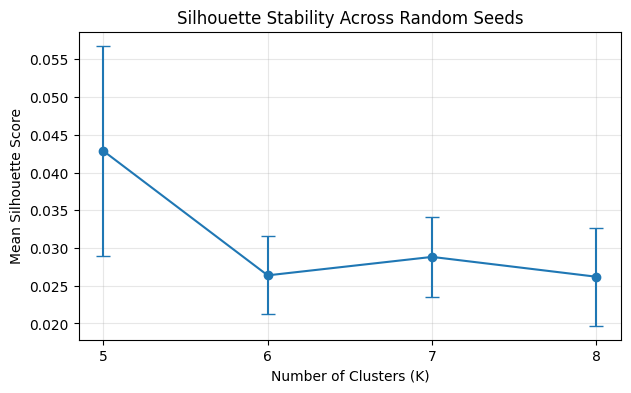

In [57]:
plt.figure(figsize=(7, 4))

plt.errorbar(
    stability_df["K"],
    stability_df["Silhouette_Mean"],
    yerr=stability_df["Silhouette_STD"],
    marker="o",
    capsize=5
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Mean Silhouette Score")
plt.title("Silhouette Stability Across Random Seeds")

plt.xticks(candidate_k)
plt.grid(alpha=0.3)

plt.show()

In [58]:
# ============================================================
# CELL 5C — Cluster Size Comparison
# ============================================================

for k in candidate_k:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    print(f"\nCluster sizes for K = {k}")
    print(cluster_sizes.to_string())


Cluster sizes for K = 5
0    107
1    279
2     63
3     25
4    136

Cluster sizes for K = 6
0     90
1    141
2     17
3    229
4     64
5     69

Cluster sizes for K = 7
0    103
1     75
2    200
3     33
4     27
5     24
6    148

Cluster sizes for K = 8
0     49
1     30
2    160
3     89
4      1
5    193
6     73
7     15


In [59]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — Chạy K-Means với K tối ưu
#          ↑ Chỉnh K_OPTIMAL dựa theo biểu đồ Elbow ở Cell 5
# ═══════════════════════════════════════════════════════════════════
K_OPTIMAL = 5

kmeans         = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Gắn nhãn cluster vào user_genre_df (inactive users = NaN)
user_genre_df['cluster'] = np.nan
user_genre_df.loc[active_users.index, 'cluster'] = cluster_labels

db_final = davies_bouldin_score(X_scaled, cluster_labels)
print(f'K = {K_OPTIMAL}  |  Davies-Bouldin Index = {db_final:.4f}')
print()
print('Số user trong mỗi cluster:')
for cid, cnt in pd.Series(cluster_labels).value_counts().sort_index().items():
    print(f'  Cluster {cid}: {cnt} users')

K = 5  |  Davies-Bouldin Index = 2.6753

Số user trong mỗi cluster:
  Cluster 0: 107 users
  Cluster 1: 279 users
  Cluster 2: 63 users
  Cluster 3: 25 users
  Cluster 4: 136 users


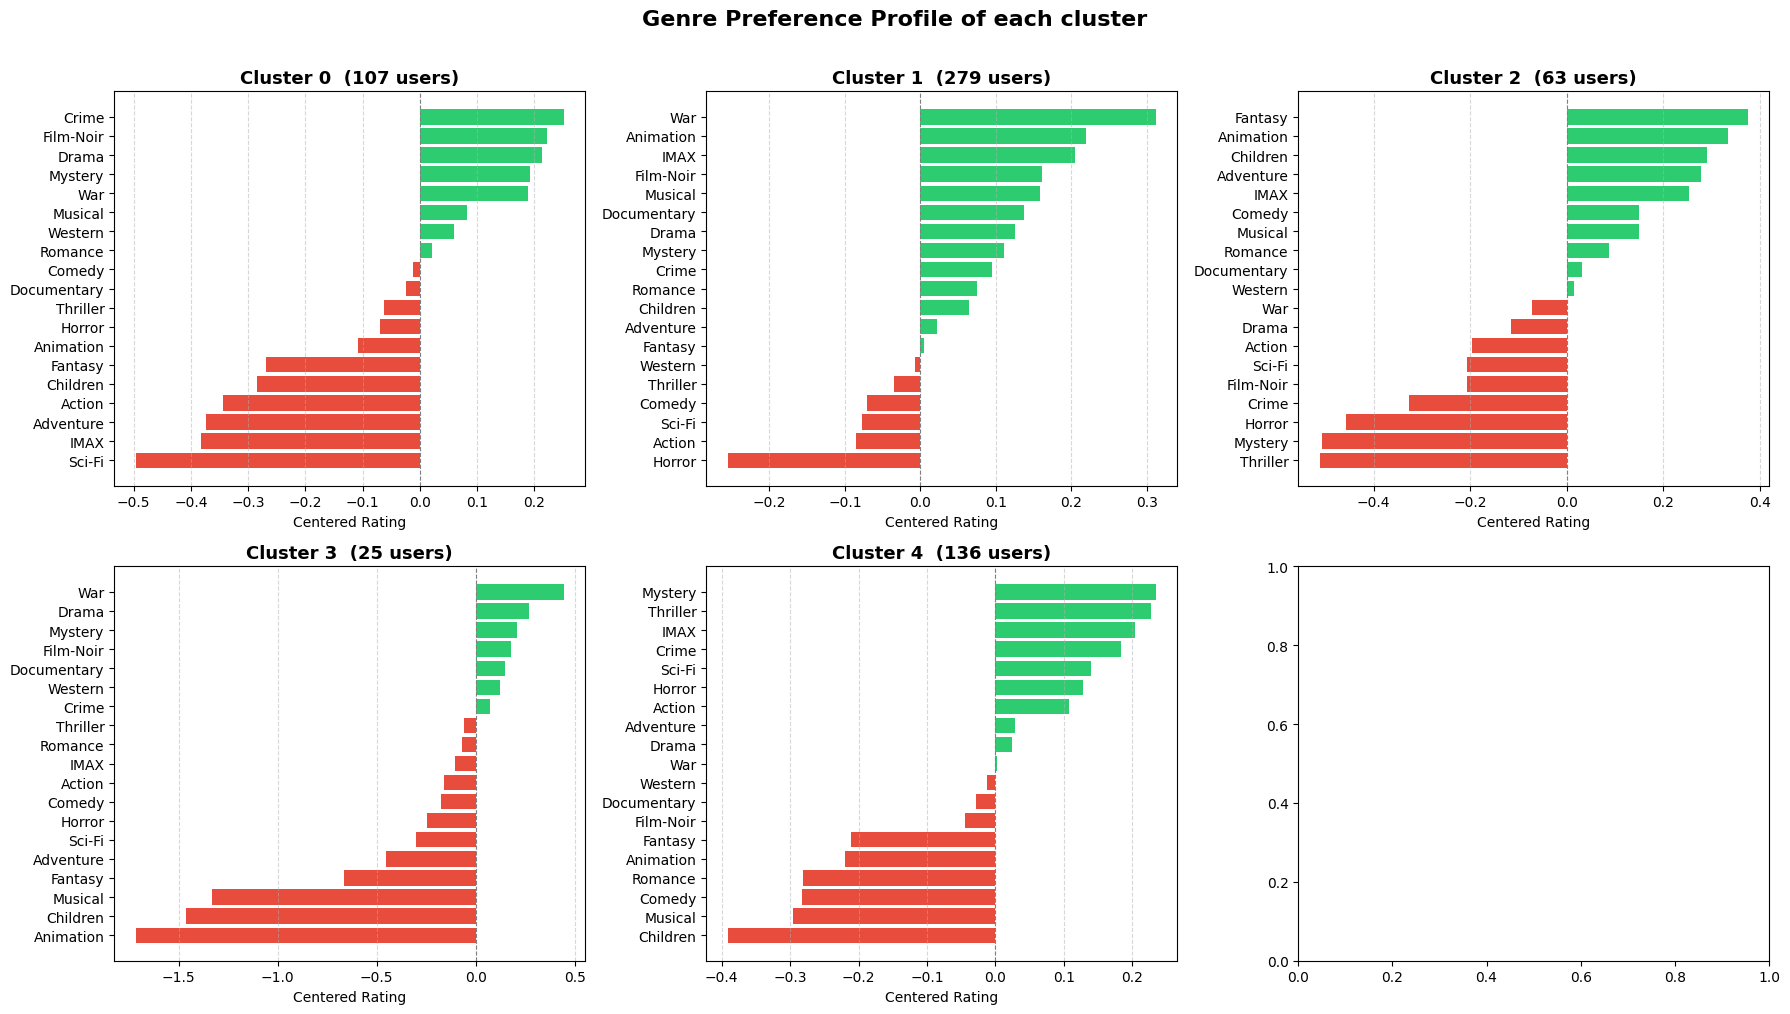

In [60]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — Phân tích đặc trưng từng cluster
#          Top genre nổi bật → hiểu cluster này thích thể loại nào
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for cid in range(K_OPTIMAL):
    cluster_idx = user_genre_df[user_genre_df['cluster'] == cid].index
    cluster_avg = user_genre_df.loc[cluster_idx, genre_cols].mean().sort_values(ascending=False)
    top_genres  = cluster_avg

    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in top_genres.values]
    axes[cid].barh(top_genres.index[::-1], top_genres.values[::-1], color=colors[::-1])
    axes[cid].set_title(f'Cluster {cid}  ({len(cluster_idx)} users)', fontsize=13, fontweight='bold')
    axes[cid].set_xlabel('Centered Rating', fontsize=10)
    axes[cid].axvline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[cid].grid(True, axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Genre Preference Profile of each cluster', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [61]:
user_genre_df[['cluster']].head(20)

,cluster
userId,
1,1.0
2,1.0
3,4.0
4,1.0
5,0.0
6,1.0
7,4.0
8,1.0
9,2.0


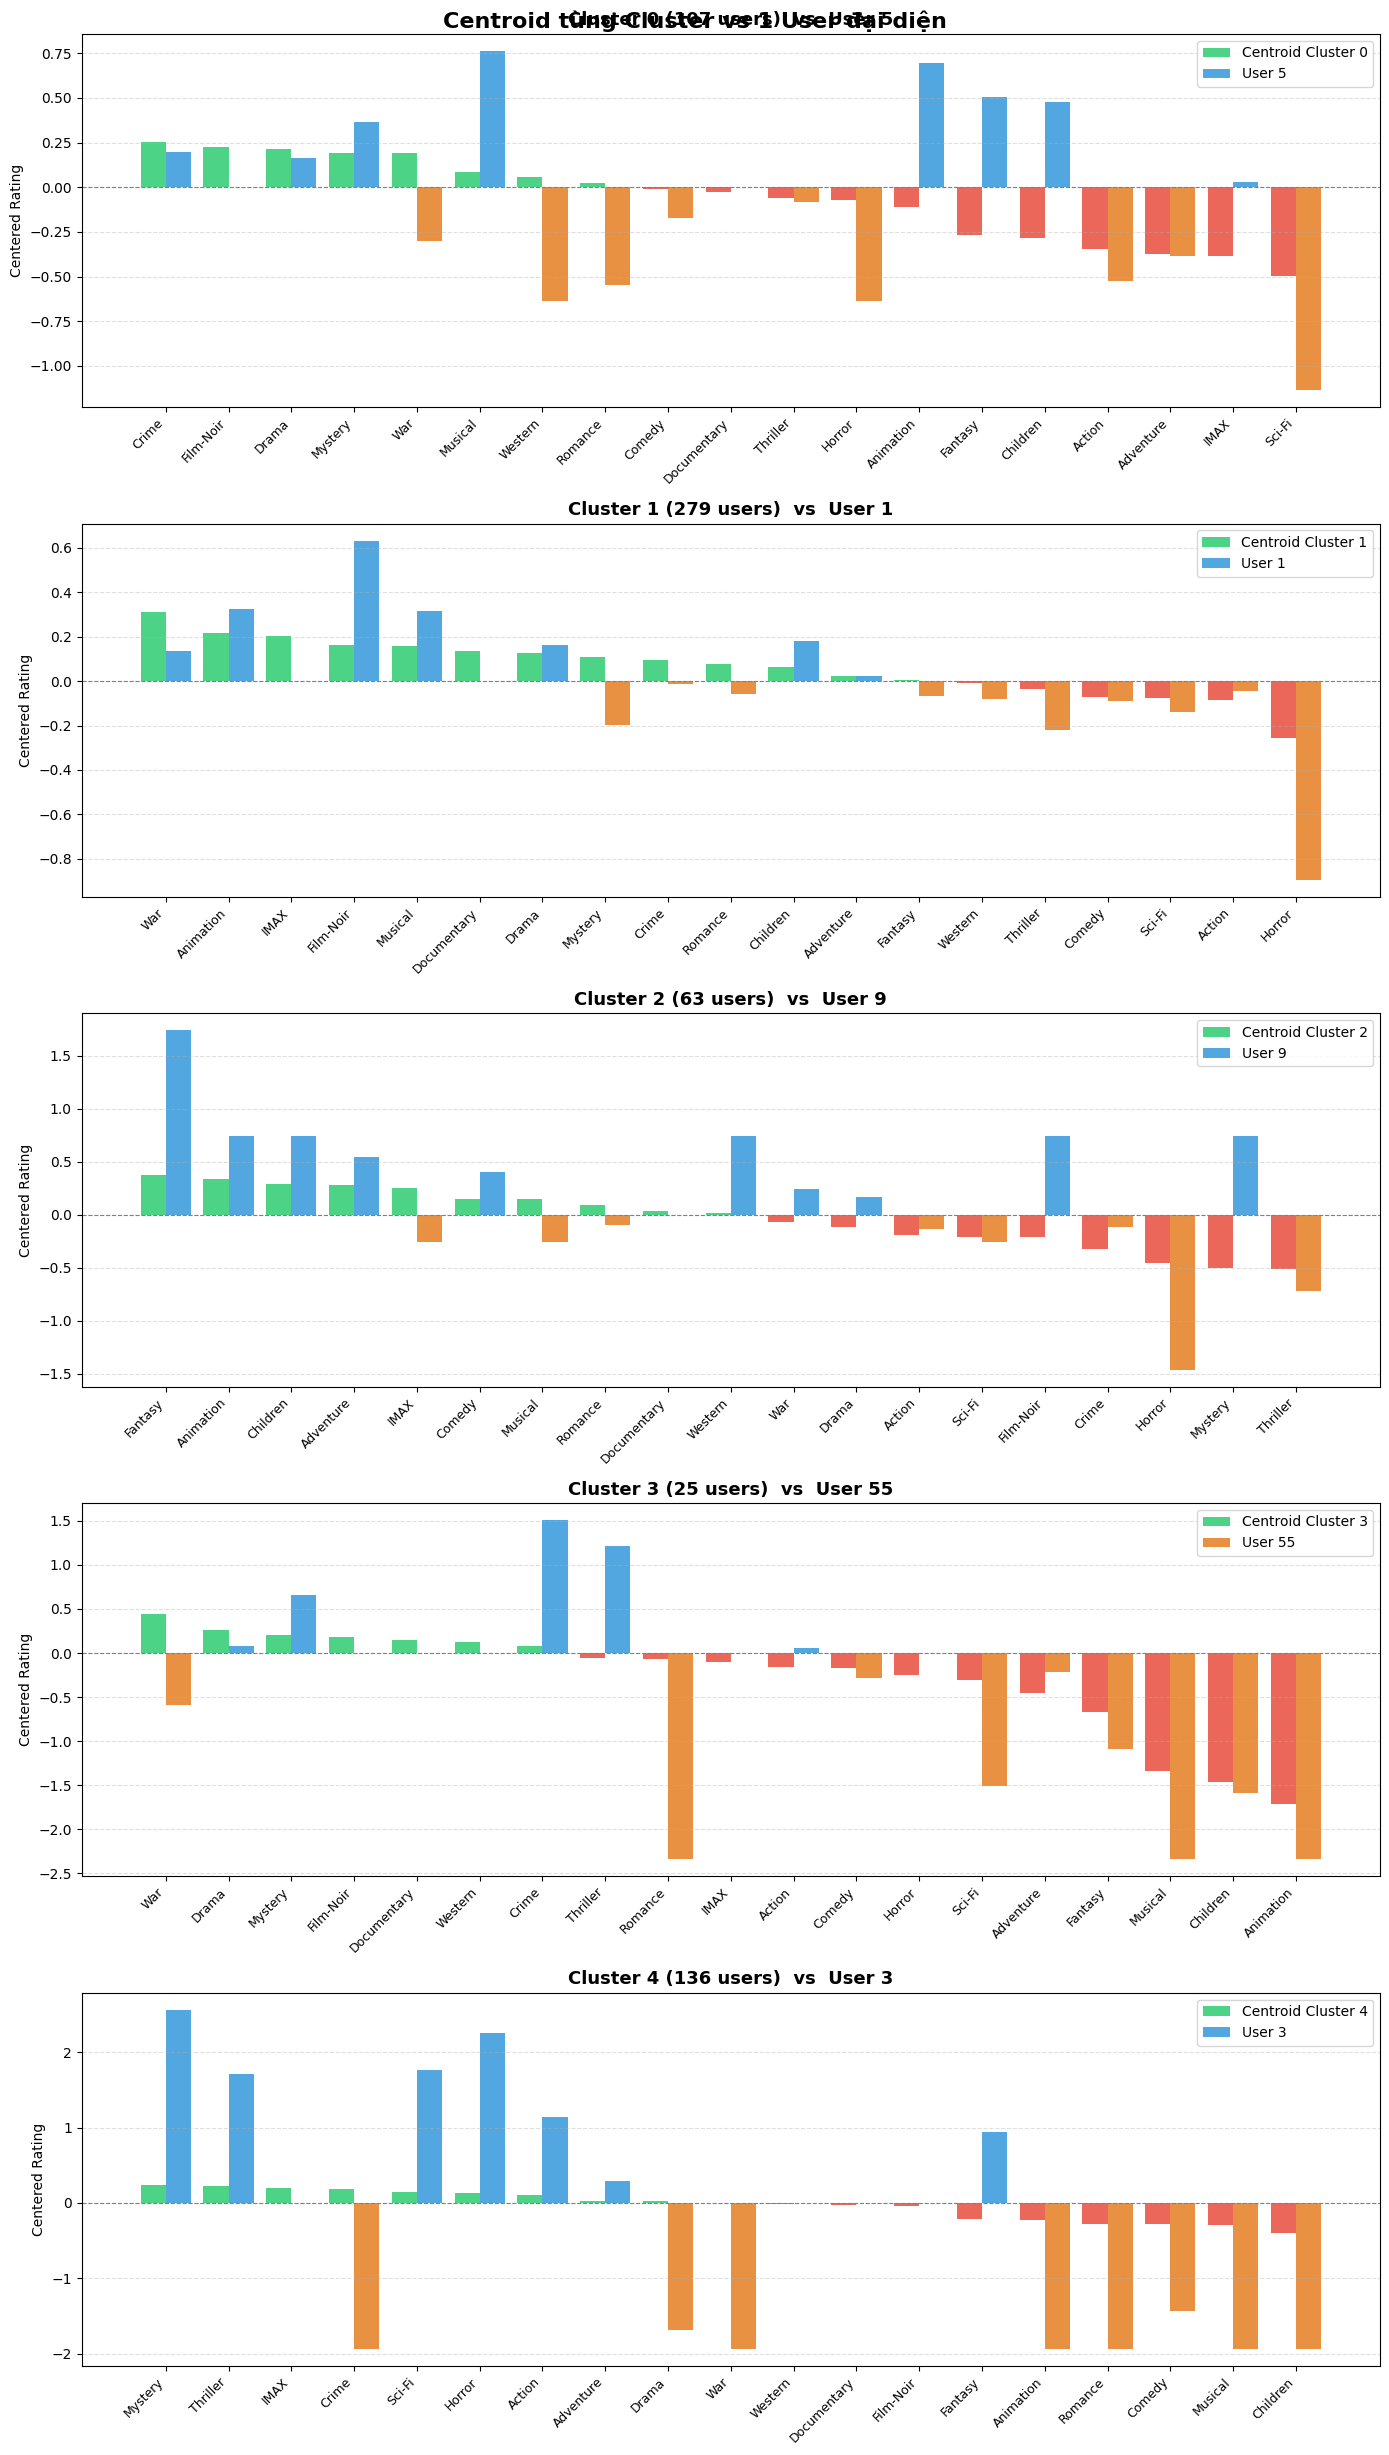

In [62]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — Phân tích đặc trưng từng cluster + so sánh với 1 user
# ═══════════════════════════════════════════════════════════════════
SAMPLE_USER_PER_CLUSTER = {cid: user_genre_df[user_genre_df['cluster'] == cid].index[0]
                           for cid in range(K_OPTIMAL)}
# Hoặc tự chọn tay: {0: 3, 1: 1, 2: 41, 3: 4, 4: 15, 5: 6}

fig, axes = plt.subplots(K_OPTIMAL, 1, figsize=(14, K_OPTIMAL * 5))

for cid in range(K_OPTIMAL):
    cluster_idx  = user_genre_df[user_genre_df['cluster'] == cid].index
    cluster_avg  = user_genre_df.loc[cluster_idx, genre_cols].mean().sort_values(ascending=False)

    sample_uid   = SAMPLE_USER_PER_CLUSTER[cid]
    user_vals    = user_genre_df.loc[sample_uid, genre_cols].reindex(cluster_avg.index)

    x      = np.arange(len(genre_cols))
    width  = 0.4
    ax     = axes[cid]

    bars_cluster = ax.bar(x - width/2, cluster_avg.values, width,
                          label=f'Centroid Cluster {cid}',
                          color=['#2ecc71' if v >= 0 else '#e74c3c' for v in cluster_avg.values],
                          alpha=0.85)
    bars_user    = ax.bar(x + width/2, user_vals.values, width,
                          label=f'User {sample_uid}',
                          color=['#3498db' if v >= 0 else '#e67e22' for v in user_vals.values],
                          alpha=0.85)

    ax.set_title(f'Cluster {cid} ({len(cluster_idx)} users)  vs  User {sample_uid}',
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cluster_avg.index, rotation=45, ha='right', fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Centered Rating')
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Centroid từng Cluster vs 1 User đại diện', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

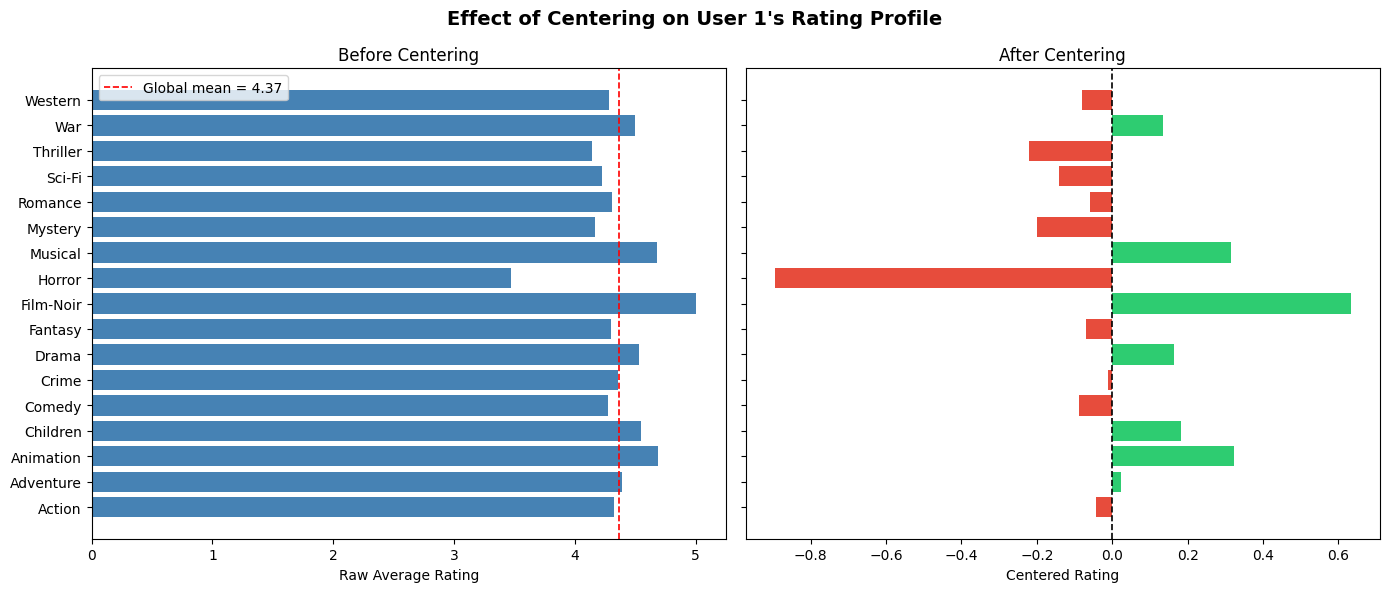

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Lấy data User 1
uid = 1
user_avg = user_genre_df.loc[uid, 'user_avg']
raw_avg  = genre_avg.loc[uid, genre_cols]       # raw per-genre average
centered = user_genre_df.loc[uid, genre_cols]   # centered

# Chỉ lấy genre user đã xem (raw != NaN trước fillna)
seen_mask = genre_count.loc[uid, genre_cols] > 0
raw_seen      = raw_avg[seen_mask]
centered_seen = centered[seen_mask]
genres_seen   = raw_seen.index.tolist()

x = np.arange(len(genres_seen))
colors_c = ['#2ecc71' if v >= 0 else '#e74c3c' for v in centered_seen]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Effect of Centering on User 1's Rating Profile", fontsize=14, fontweight='bold')

# LEFT — raw
axes[0].barh(x, raw_seen, color='steelblue')
axes[0].axvline(user_avg, color='red', linestyle='--', linewidth=1.2, label=f'Global mean = {user_avg:.2f}')
axes[0].set_yticks(x)
axes[0].set_yticklabels(genres_seen)
axes[0].set_xlabel('Raw Average Rating')
axes[0].set_title('Before Centering')
axes[0].legend()
axes[0].invert_yaxis()

# RIGHT — centered
axes[1].barh(x, centered_seen, color=colors_c)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Centered Rating')
axes[1].set_title('After Centering')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [64]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — Recommendation Functions
#
# 3 trường hợp:
# ┌────────────────────────────┬──────────────────────────────────────┐
# │ New user (0 rating)        │ Favorite genres → nearest cluster   │
# │                            │ or Popular Fallback                  │
# ├────────────────────────────┼──────────────────────────────────────┤
# │ Weak-profile user          │ Not enough ratings → Popular        │
# │ (< MIN_RATINGS)            │ Fallback                            │
# ├────────────────────────────┼──────────────────────────────────────┤
# │ Active user                │ K-Means cluster → recommend unseen  │
# │ (>= MIN_RATINGS)           │ movies from users in same cluster   │
# └────────────────────────────┴──────────────────────────────────────┘
# ═══════════════════════════════════════════════════════════════════


# -------------------------------------------------------------------
# 1. Recommend movies from a specific cluster
# -------------------------------------------------------------------
def recommend_from_cluster(
    cluster_id,
    exclude_movies=None,
    exclude_user=None,
    top_n=10,
    min_cluster_ratings=3
):
    """
    Cluster-based recommendation.

    Quy trình:
      1. Lấy các user thuộc cùng cluster
      2. Loại target user nếu cần
      3. Tổng hợp rating của từng movie trong cluster
      4. Loại phim target user đã xem
      5. Loại phim có quá ít rating trong cluster
      6. Tính weighted score
      7. Trả về Top-N movie
    """

    if exclude_movies is None:
        exclude_movies = set()

    # Lấy danh sách user trong cluster
    cluster_users = (
        user_genre_df[
            user_genre_df["cluster"] == cluster_id
        ]
        .index
        .tolist()
    )

    # Loại target user để recommendation không dùng chính lịch sử của user đó
    if exclude_user is not None:
        cluster_users = [
            user_id
            for user_id in cluster_users
            if user_id != exclude_user
        ]

    # Nếu cluster không còn user nào
    if len(cluster_users) == 0:
        print("⚠️ Cluster không có user phù hợp → Popular Fallback")
        return recommend_popular(top_n=top_n)

    # Ratings từ các user cùng cluster
    cluster_ratings = ratings[
        ratings["userId"].isin(cluster_users)
    ]

    # Thống kê movie trong cluster
    movie_stats = (
        cluster_ratings
        .groupby("movieId")["rating"]
        .agg(
            avg_rating="mean",
            rating_count="count"
        )
    )

    # Weighted score:
    # rating cao + được nhiều user trong cluster đánh giá
    #
    # log1p giúp rating_count có ảnh hưởng,
    # nhưng không để phim quá phổ biến lấn át hoàn toàn avg_rating.
    movie_stats["score"] = (
        movie_stats["avg_rating"]
        * np.log1p(movie_stats["rating_count"])
    )

    # Lọc:
    # - đủ số rating tối thiểu trong cluster
    # - user chưa xem
    filtered = movie_stats[
        (movie_stats["rating_count"] >= min_cluster_ratings)
        &
        (~movie_stats.index.isin(exclude_movies))
    ]

    # Nếu không còn candidate
    if filtered.empty:
        print("⚠️ Không đủ candidate trong cluster → Popular Fallback")
        return recommend_popular(top_n=top_n)

    # Ranking theo weighted score
    result = (
        filtered
        .sort_values(
            ["score", "avg_rating", "rating_count"],
            ascending=[False, False, False]
        )
        .head(top_n)
        .join(
            movies.set_index("movieId"),
            how="inner"
        )
        .reset_index()
    )

    result["cluster"] = int(cluster_id)

    return result[
        [
            "movieId",
            "title",
            "genres",
            "avg_rating",
            "rating_count",
            "score",
            "cluster"
        ]
    ]


# -------------------------------------------------------------------
# 2. Popular fallback
# -------------------------------------------------------------------
def recommend_popular(
    top_n=10,
    min_ratings=50
):
    """
    Fallback recommendation.

    Dùng khi:
      - user mới không cung cấp genre
      - genre không hợp lệ
      - user có quá ít rating
      - cluster không đủ candidate

    Ranking:
      avg_rating cao trước
      → nếu bằng nhau thì ưu tiên rating_count cao hơn.
    """

    movie_stats = (
        ratings
        .groupby("movieId")["rating"]
        .agg(
            avg_rating="mean",
            rating_count="count"
        )
    )

    filtered = movie_stats[
        movie_stats["rating_count"] >= min_ratings
    ]

    result = (
        filtered
        .sort_values(
            ["avg_rating", "rating_count"],
            ascending=[False, False]
        )
        .head(top_n)
        .join(
            movies.set_index("movieId"),
            how="inner"
        )
        .reset_index()
    )

    # -1 dùng để biểu diễn Popular Fallback
    result["cluster"] = -1

    return result[
        [
            "movieId",
            "title",
            "genres",
            "avg_rating",
            "rating_count",
            "cluster"
        ]
    ]


# -------------------------------------------------------------------
# 3. Existing user recommendation
# -------------------------------------------------------------------
def recommend_for_existing_user(
    user_id,
    top_n=10
):
    """
    Recommendation cho user đã tồn tại trong dataset.

    Nếu user đủ rating:
        → dùng cluster-based recommendation.

    Nếu user không đủ rating:
        → Popular Fallback.
    """

    # Kiểm tra user
    if user_id not in user_genre_df.index:
        print(f"❌ Không tìm thấy userId {user_id}")
        return None

    user_row = user_genre_df.loc[user_id]

    rating_count = int(
        user_row["rating_count"]
    )

    print(
        f"userId = {user_id}"
        f" | Số phim đã rate: {rating_count}"
        f" | user_avg: {user_row['user_avg']:.2f}"
    )

    # Weak-profile user
    if pd.isna(user_row["cluster"]):

        print(
            f"⚠️ Ít hơn {MIN_RATINGS} ratings"
            " → Weak profile"
            " → Popular Fallback"
        )

        return recommend_popular(
            top_n=top_n
        )

    # Active user
    cluster_id = int(
        user_row["cluster"]
    )

    watched_movies = set(
        ratings[
            ratings["userId"] == user_id
        ]["movieId"]
    )

    print(
        f"✅ Thuộc Cluster {cluster_id}"
        f" | Đã xem: {len(watched_movies)} phim"
    )

    return recommend_from_cluster(
        cluster_id=cluster_id,
        exclude_movies=watched_movies,
        exclude_user=user_id,
        top_n=top_n
    )


# -------------------------------------------------------------------
# 4. New user recommendation
# -------------------------------------------------------------------
def recommend_for_new_user(
    favorite_genres=None,
    top_n=10
):
    """
    Recommendation cho user hoàn toàn mới.

    Nếu user chọn favorite genres:
        → tạo approximate genre-preference vector
        → scale bằng scaler đã train
        → tìm K-Means centroid gần nhất
        → recommend từ cluster đó.

    Nếu không có genre:
        → Popular Fallback.
    """

    # Không cung cấp genre
    if not favorite_genres:
        print(
            "ℹ️ Không có favorite genre"
            " → Popular Fallback"
        )

        return recommend_popular(
            top_n=top_n
        )

    # Chỉ giữ genre hợp lệ
    valid_genres = [
        genre
        for genre in favorite_genres
        if genre in genre_cols
    ]

    # Không có genre hợp lệ
    if not valid_genres:

        print(
            "⚠️ Không có genre hợp lệ."
        )

        print(
            f"Genres hợp lệ: {genre_cols}"
        )

        return recommend_popular(
            top_n=top_n
        )

    # ---------------------------------------------------------------
    # Approximate preference vector
    #
    # Favorite genre = 1.0
    # Other genres   = 0.0
    #
    # Đây là profile xấp xỉ cho cold-start user.
    # ---------------------------------------------------------------
    preference_vector = np.array(
        [
            1.0 if genre in valid_genres else 0.0
            for genre in genre_cols
        ]
    ).reshape(1, -1)

    # Scale bằng scaler đã fit trên training user profiles
    preference_scaled = scaler.transform(
        preference_vector
    )

    # ---------------------------------------------------------------
    # Tìm centroid gần nhất
    # ---------------------------------------------------------------
    distances = np.linalg.norm(
    kmeans.cluster_centers_
    - preference_scaled,
    axis=1
)
    best_cluster = int(
        np.argmin(distances)
    )

    print(
        f"✅ Favorite genres: {valid_genres}"
        f" → Nearest Cluster: {best_cluster}"
    )

    return recommend_from_cluster(
        cluster_id=best_cluster,
        exclude_movies=set(),
        top_n=top_n
    )


# -------------------------------------------------------------------
# 5. View movies already watched by a user
# -------------------------------------------------------------------
def get_user_watched(
    user_id,
    top_n=None
):
    """
    Xem lịch sử rating của user.
    Sắp xếp theo rating giảm dần.
    """

    if user_id not in ratings["userId"].values:

        print(
            f"❌ Không tìm thấy userId {user_id}"
        )

        return None

    result = (
        ratings[
            ratings["userId"] == user_id
        ]
        .merge(
            movies,
            on="movieId"
        )[
            [
                "movieId",
                "title",
                "genres",
                "rating"
            ]
        ]
        .sort_values(
            "rating",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    result.index += 1

    if top_n:
        return result.head(top_n)

    return result


# -------------------------------------------------------------------
# Ready
# -------------------------------------------------------------------
print("✅ Recommendation functions ready")
print(f"📋 Valid genres: {genre_cols}")

✅ Recommendation functions ready
📋 Valid genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [65]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — Demo: Gợi ý cho user đã có trong hệ thống
# ═══════════════════════════════════════════════════════════════════
TARGET_USER = 1  # ← đổi userId tùy ý (1 – 610)

print(f'{'='*60}')
print(f'  Phim user {TARGET_USER} đã xem (top 10 theo rating)')
print(f'{'='*60}')
display(get_user_watched(TARGET_USER, top_n=10))

print()
print(f'{'='*60}')
print(f'  PHIM GỢI Ý CHO USER {TARGET_USER}')
print(f'{'='*60}')
recs = recommend_for_existing_user(TARGET_USER, top_n=10)
print()
display(recs)

  Phim user 1 đã xem (top 10 theo rating)


,movieId,title,genres,rating
1,5060,M*A*S*H (a.k.a. MASH) (1970),Comedy|Drama|War,5.0
2,2872,Excalibur (1981),Adventure|Fantasy,5.0
3,1291,Indiana Jones and the Last Crusade (1989),Action|Adventure,5.0
4,1298,Pink Floyd: The Wall (1982),Drama|Musical,5.0
5,2948,From Russia with Love (1963),Action|Adventure|Thriller,5.0
6,2947,Goldfinger (1964),Action|Adventure|Thriller,5.0
7,2944,"Dirty Dozen, The (1967)",Action|Drama|War,5.0
8,2899,Gulliver's Travels (1939),Adventure|Animation|Children,5.0
9,2858,American Beauty (1999),Drama|Romance,5.0
10,2700,"South Park: Bigger, Longer and Uncut (1999)",Animation|Comedy|Musical,5.0



  PHIM GỢI Ý CHO USER 1
userId = 1 | Số phim đã rate: 232 | user_avg: 4.37
✅ Thuộc Cluster 1 | Đã xem: 232 phim



,movieId,title,genres,avg_rating,rating_count,score,cluster
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.503226,155,22.740642,1
1,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,4.100806,124,19.799980,1
2,7153,"Lord of the Rings: The Return of the King, The (2003)",Action|Adventure|Drama|Fantasy,4.182243,107,19.581811,1
3,858,"Godfather, The (1972)",Crime|Drama,4.324176,91,19.553009,1
4,4226,Memento (2000),Mystery|Thriller,4.325843,89,19.465469,1
5,4993,"Lord of the Rings: The Fellowship of the Ring, The (2001)",Adventure|Fantasy,4.107143,112,19.416057,1
6,364,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,4.084112,107,19.122349,1
7,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,4.050926,108,19.004303,1
8,588,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,3.977876,113,18.840011,1
9,150,Apollo 13 (1995),Adventure|Drama|IMAX,3.973451,113,18.819054,1


In [71]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10 — Demo: Recommendation for New Users
# ═══════════════════════════════════════════════════════════════════


# -------------------------------------------------------------------
# CASE 1 — New user provides favorite genres
# -------------------------------------------------------------------
print("=" * 70)
print("NEW USER — Favorite genres: Drama, War, Crime")
print("=" * 70)

recs_new = recommend_for_new_user(
    favorite_genres=[
        "Thriller",
        "Comedy",
        "IMAX"
    ],
    top_n=10
)

print("\nTop recommendations:")
display(recs_new)


# -------------------------------------------------------------------
# CASE 2 — New user provides no favorite genres
#          → Popular Fallback
# -------------------------------------------------------------------
print("\n" + "=" * 70)
print("NEW USER — No favorite genres → Popular Fallback")
print("=" * 70)

recs_popular = recommend_for_new_user(
    favorite_genres=None,
    top_n=10
)

print("\nTop popular recommendations:")
display(recs_popular)

NEW USER — Favorite genres: Drama, War, Crime
✅ Favorite genres: ['Thriller', 'Comedy', 'IMAX'] → Nearest Cluster: 1

Top recommendations:


,movieId,title,genres,avg_rating,rating_count,score,cluster
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.503226,155,22.740642,1
1,356,Forrest Gump (1994),Comedy|Drama|Romance|War,4.245763,177,22.000623,1
2,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,4.368613,137,21.525265,1
3,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.278912,147,21.382629,1
4,527,Schindler's List (1993),Drama|War,4.548544,103,21.125215,1
5,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,4.067485,163,20.743628,1
6,1196,Star Wars: Episode V - The Empire Strikes Back (1980),Action|Adventure|Sci-Fi,4.285124,121,20.585826,1
7,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,4.137324,142,20.532896,1
8,2959,Fight Club (1999),Action|Crime|Drama|Thriller,4.262712,118,20.372026,1
9,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,4.292793,111,20.255538,1



NEW USER — No favorite genres → Popular Fallback
ℹ️ Không có favorite genre → Popular Fallback

Top popular recommendations:


,movieId,title,genres,avg_rating,rating_count,cluster
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.429022,317,-1
1,858,"Godfather, The (1972)",Crime|Drama,4.289062,192,-1
2,2959,Fight Club (1999),Action|Crime|Drama|Thriller,4.272936,218,-1
3,1276,Cool Hand Luke (1967),Drama,4.271930,57,-1
4,750,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),Comedy|War,4.268041,97,-1
5,904,Rear Window (1954),Mystery|Thriller,4.261905,84,-1
6,1221,"Godfather: Part II, The (1974)",Crime|Drama,4.259690,129,-1
7,48516,"Departed, The (2006)",Crime|Drama|Thriller,4.252336,107,-1
8,1213,Goodfellas (1990),Crime|Drama,4.250000,126,-1
9,912,Casablanca (1942),Drama|Romance,4.240000,100,-1


In [73]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11 — Interactive: Nhập User ID từ bàn phím
# ═══════════════════════════════════════════════════════════════════
user_input = int(input('Nhập User ID (1–610): '))

print()
print(f'{'='*60}')
print(f'  PHIM GỢI Ý CHO USER {user_input}')
print(f'{'='*60}')
recs_input = recommend_for_existing_user(user_input, top_n=10)
if recs_input is not None:
    print()
    display(recs_input)


  PHIM GỢI Ý CHO USER 50
userId = 50 | Số phim đã rate: 310 | user_avg: 2.78
✅ Thuộc Cluster 0 | Đã xem: 310 phim



,movieId,title,genres,avg_rating,rating_count,score,cluster
0,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.239130,46,16.321278,0
1,527,Schindler's List (1993),Drama|War,4.070000,50,16.002530,0
2,2858,American Beauty (1999),Drama|Romance,4.153846,39,15.323038,0
3,1193,One Flew Over the Cuckoo's Nest (1975),Drama,4.287879,33,15.120606,0
4,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,4.065789,38,14.895270,0
5,7361,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi,4.232143,28,14.250877,0
6,1213,Goodfellas (1990),Crime|Drama,4.307692,26,14.197451,0
7,2329,American History X (1998),Crime|Drama,4.395833,24,14.149642,0
8,1089,Reservoir Dogs (1992),Crime|Mystery|Thriller,4.196429,28,14.130616,0
9,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",Comedy|Romance,4.196429,28,14.130616,0
